Shape: (7043, 21)

Data Types:

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract          

<ipython-input-63-015e81faabda>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


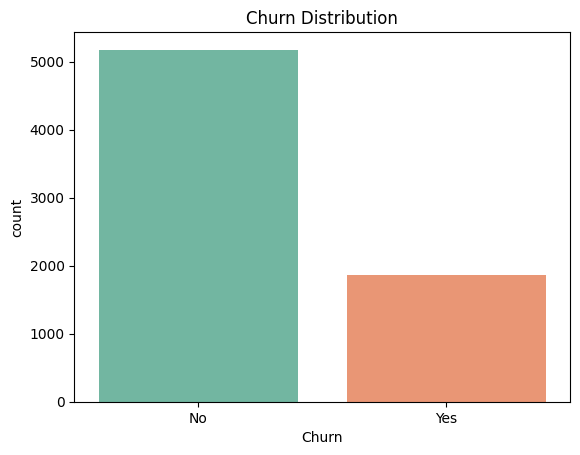

Null TotalCharges: 11


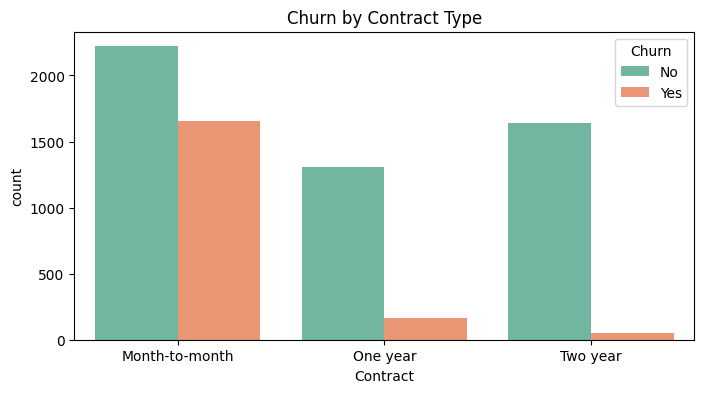

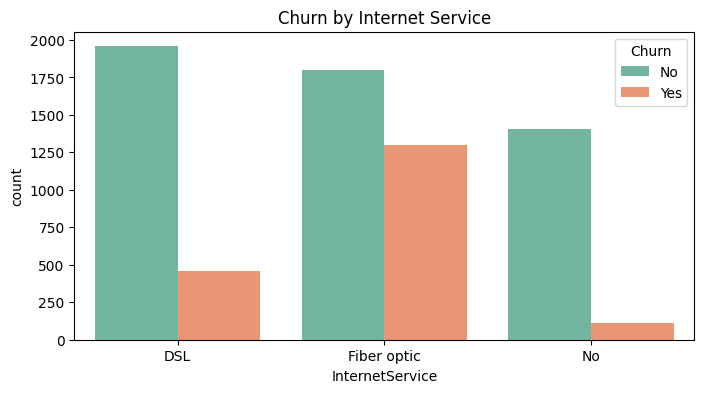

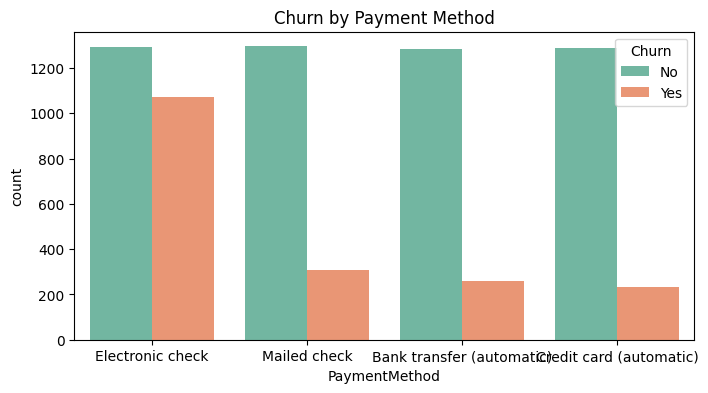

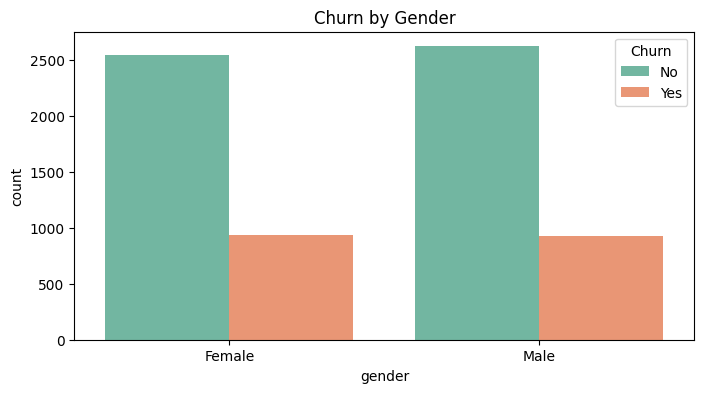

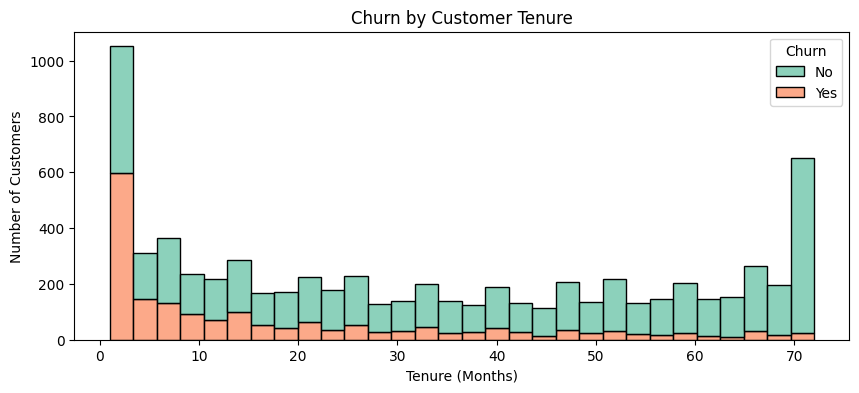

Data shape after encoding: (7032, 31)
Accuracy: 0.8038379530916845

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

Accuracy: 0.7882018479033405

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


Confusion Matrix:
 [[917 116]
 [182 192]]
Accuracy: 0.7604832977967306

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.81      0.83     

In [63]:
import pandas as pd
import io

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

df.head()

#                                         EDA

# shape & basic info
print("Shape:", df.shape)
print("\nData Types:\n")
print(df.dtypes)

# missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

# duplicates
print("\nDuplicate Values:\n")

#                                     Distribution

# value counts for target variable
print(df['Churn'].value_counts())

# Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Churn Distribution')
plt.show()

#                                    Numeric Columns

df.describe()

#                                   Fixing Data Types

# Convert Total Charges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
#Check on what values cant convert
print("Null TotalCharges:", df['TotalCharges'].isnull().sum())
# Drop missing values
df = df.dropna(subset=['TotalCharges'])
# reset index
df = df.reset_index(drop=True)

#                               Visualizing Churn by Category

# Contract type
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Churn by Contract Type')
plt.show()

# internet service
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='InternetService', hue='Churn', palette='Set2')
plt.title('Churn by Internet Service')
plt.show()

# payment method
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette='Set2')
plt.title('Churn by Payment Method')
plt.show()

# gender vs churn
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='gender', hue='Churn', palette='Set2')
plt.title('Churn by Gender')
plt.show()

#                                   Churn vs tenure

plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', palette='Set2', bins=30)
plt.title('Churn by Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

#                   Encoding categorical variables for Modeling

#drop customerid
df = df.drop('customerID', axis=1)
#convert yes/no to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
#one-hot encoding the rest
df = pd.get_dummies(df, drop_first=True)
# final check
print("Data shape after encoding:",df.shape)
df.head()

#                                   Spliting Data

from sklearn.model_selection import train_test_split

#sepeate features and target
x = df.drop('Churn', axis=1)
y = df['Churn']

#split 80% train 20% test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

#                                      Scaling data

from sklearn.preprocessing import StandardScaler
#start scaler
scaler = StandardScaler()
#fit on training and transform bith rrain and test
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

#                             Training logistic regression model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#start train
model = LogisticRegression(max_iter=1000)
model.fit(x_train_scaled, y_train)
#predict
y_pred = model.predict(x_test_scaled)
#evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

###### logistic model not good at catching churning customers #######

#                                  Random Forest

from sklearn.ensemble import RandomForestClassifier

#start train
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train_scaled, y_train)
#predict
y_pred_rf = rf_model.predict(x_test_scaled)

#evaluate

from sklearn.metrics import accuracy_score, classification_report , confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

#.     ##### Random Forest did not outperform loigstic regression ######

#                                        XgBoost

!pip install xgboost
import xgboost as xgb
from xgboost import XGBClassifier

#start xgboost classifer
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
#train on scaled features
xgb_model.fit(x_train_scaled, y_train)
#predicted prob
xgb_probs = xgb_model.predict_proba(x_test_scaled)[:, 1]
#threshold
threshold = 0.4
#predict
xgb_preds = (xgb_probs >= threshold).astype(int)

#evaluate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test, xgb_preds))
print("\nClassification Report:\n", classification_report(y_test, xgb_preds))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, xgb_preds))
